Input: 10 dim vectors
Output: binary probability (0, 1) of whether change occurred at a time
First generate data, then put binary labels if t>=T, and train neural networks to predict p(t)=P by minimizing binary cross entropy loss.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


# Generate Sequence

In [ ]:
def generate_sequence(max_length=100, change_prob=0.8):

    flag = np.random.rand() < change_prob

    if flag:
        change_point = np.random.randint(0, max_length)
    else:
        change_point = None

    sequence = np.random.randn(max_length, 10)

    if flag:
        # randomly pick components to shift
        indices = np.random.choice(10, 5, replace=False)

        shifts = np.random.uniform(-1, 1, 5)

        for i, idx in enumerate(indices):
            sequence[change_point:, idx] += shifts[i]

    # labels = 1 if has change, otherwise 0
    labels = np.zeros(max_length)
    if flag:
        labels[change_point:] = 1

    return sequence, labels, change_point


seq, labels, cp = generate_sequence()

In [4]:
class ChangePointDataset(Dataset):

    def __init__(self, num_sequences, max_length=100, change_prob=0.8):
        self.num_sequences = num_sequences
        self.max_length = max_length
        self.change_prob = change_prob

    def __len__(self):
        return self.num_sequences

    def __getitem__(self, idx):
        sequence, labels, change_point = generate_sequence(self.max_length, self.change_prob)
        return (
            torch.FloatTensor(sequence),
            torch.FloatTensor(labels),
            change_point if change_point is not None else -1
        )

# generate change point dataset

train_dataset = ChangePointDataset(num_sequences=5000, max_length=100)
val_dataset = ChangePointDataset(num_sequences=1000, max_length=100)
test_dataset = ChangePointDataset(num_sequences=1000, max_length=100)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# RNN model

In [ ]:
class RNNDetector(nn.Module):
    def __init__(self, input_size=10, hidden_size=64, num_layers=6, dropout=0.2):
        super(RNNDetector, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):

        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out)

        return out.squeeze(-1)

rnn_model = RNNDetector().to(device)
# total parameters
print(f"\n{sum(p.numel() for p in rnn_model.parameters())}")


187969


# 1D CNN model with 3 conv layers

In [ ]:
class CNNDetector(nn.Module):
    def __init__(self, input_size=10, hidden_channels=64, dropout=0.2):
        super(CNNDetector, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv1d(input_size, hidden_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.conv2 = nn.Sequential(
            nn.Conv1d(hidden_channels, hidden_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.conv3 = nn.Sequential(
            nn.Conv1d(hidden_channels, hidden_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.output = nn.Sequential(
            nn.Conv1d(hidden_channels, 32, kernel_size=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(32, 1, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.transpose(1, 2)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        x = self.output(x)
        return x.squeeze(1)

cnn_model = CNNDetector().to(device)
print(f"\nTotal parameters: {sum(p.numel() for p in cnn_model.parameters())}")


Total parameters: 46849


# Training and evaluating functions

In [7]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for sequences, labels, _ in loader:
        sequences = sequences.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(sequences)

        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)



In [8]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for sequences, labels, _ in loader:
            sequences = sequences.to(device)
            labels = labels.to(device)

            outputs = model(sequences)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

    return total_loss / len(loader)


def train_model(model, train_loader, val_loader, num_epochs=30, lr=0.001, patience=5):

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping: {epoch+1}")
                break

    model.load_state_dict(best_model_state)

    return train_losses, val_losses

# Training

In [9]:
rnn_train_losses, rnn_val_losses = train_model(rnn_model, train_loader, val_loader, num_epochs=30, lr=0.001)

Epoch 1 | train loss: 0.6432 | val loss: 0.5841
Epoch 2 | train loss: 0.5373 | val loss: 0.3951
Epoch 3 | train loss: 0.3542 | val loss: 0.3117
Epoch 4 | train loss: 0.2950 | val loss: 0.2813
Epoch 5 | train loss: 0.2863 | val loss: 0.2794
Epoch 6 | train loss: 0.2808 | val loss: 0.2701
Epoch 7 | train loss: 0.2783 | val loss: 0.2655
Epoch 8 | train loss: 0.2794 | val loss: 0.2707
Epoch 9 | train loss: 0.2721 | val loss: 0.2664
Epoch 10 | train loss: 0.2686 | val loss: 0.2685
Epoch 11 | train loss: 0.2677 | val loss: 0.2565
Epoch 12 | train loss: 0.2708 | val loss: 0.2595
Epoch 13 | train loss: 0.2730 | val loss: 0.2550
Epoch 14 | train loss: 0.2636 | val loss: 0.2644
Epoch 15 | train loss: 0.2724 | val loss: 0.2572
Epoch 16 | train loss: 0.2686 | val loss: 0.2564
Epoch 17 | train loss: 0.2650 | val loss: 0.2629
Epoch 18 | train loss: 0.2622 | val loss: 0.2590
Early stopping: 18


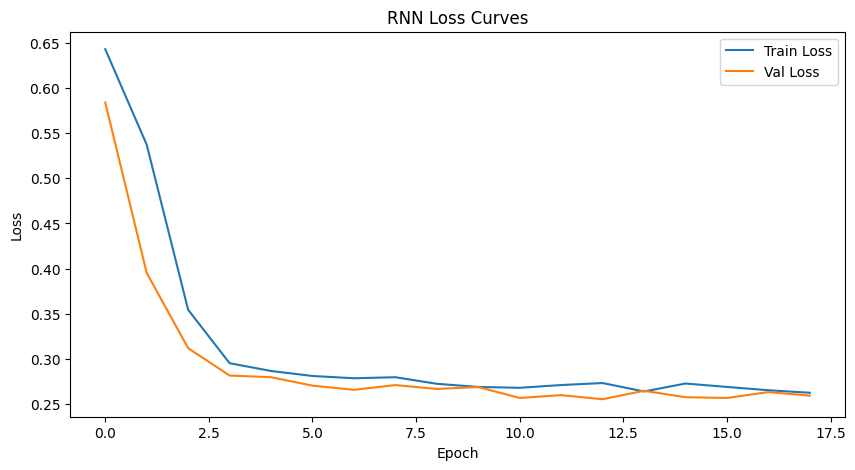

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(rnn_train_losses, label='Train Loss')
plt.plot(rnn_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN Loss Curves')
plt.legend()
plt.show()

Output 1 [output1.png] RNN loss curves

The loss curves seem consistent, after adding to 6 layers from original 2 layers. That is, dilation increased. The loss is a little high, reaching a platuea early, possibly because of the complexity.

In [11]:
cnn_train_losses, cnn_val_losses = train_model(cnn_model, train_loader, val_loader, num_epochs=30, lr=0.001)

Epoch 1 | train loss: 0.5219 | val loss: 0.3662
Epoch 2 | train loss: 0.4239 | val loss: 0.3558
Epoch 3 | train loss: 0.3997 | val loss: 0.3271
Epoch 4 | train loss: 0.3893 | val loss: 0.3148
Epoch 5 | train loss: 0.3820 | val loss: 0.3265
Epoch 6 | train loss: 0.3739 | val loss: 0.3290
Epoch 7 | train loss: 0.3728 | val loss: 0.3301
Epoch 8 | train loss: 0.3707 | val loss: 0.2860
Epoch 9 | train loss: 0.3655 | val loss: 0.3066
Epoch 10 | train loss: 0.3698 | val loss: 0.3020
Epoch 11 | train loss: 0.3630 | val loss: 0.3272
Epoch 12 | train loss: 0.3664 | val loss: 0.3121
Epoch 13 | train loss: 0.3657 | val loss: 0.2982
Early stopping: 13


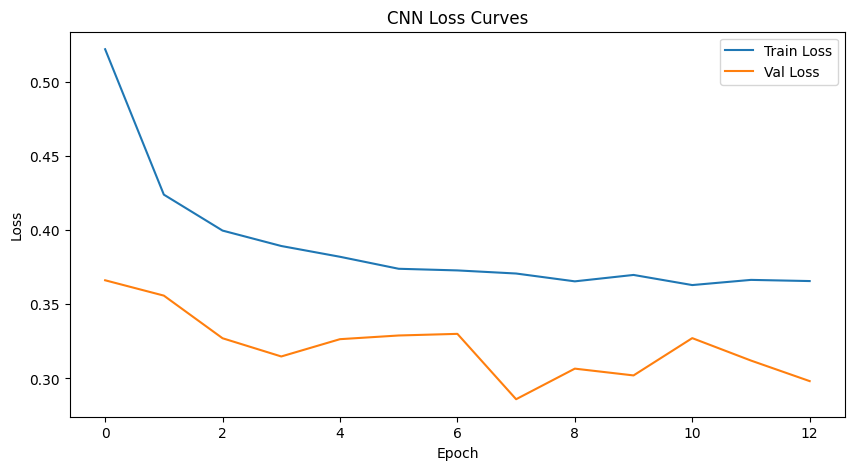

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(cnn_train_losses, label='Train Loss')
plt.plot(cnn_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss Curves')
plt.legend()
plt.show()

Output 2 [output2.png] CNN loss curves

It seems like CNN can't solve this problem with a good loss, which is no lower than 0.30. It's likely that CNN can't integrate information ammong the full sequence, and CNN can't see further than a small local window around each step.

# analyze probabilities

In [ ]:
def detection_probability(model, num_samples=500, max_length=100):
    model.eval()

    dist_to_probs = {}

    with torch.no_grad():
        for _ in range(num_samples):

            sequence, labels, change_point = generate_sequence(max_length, change_prob=1.0)

            if change_point is None:
                continue

            # get predictions, then record probability for each time step

            seq_tensor = torch.FloatTensor(sequence).unsqueeze(0).to(device)
            probs = model(seq_tensor).squeeze().cpu().numpy()

            for t in range(max_length):
                dist = t - change_point

                if dist not in dist_to_probs:
                    dist_to_probs[dist] = []

                dist_to_probs[dist].append(probs[t])

    meanProbDist = {}
    for dist, probs in dist_to_probs.items():
        meanProbDist[dist] = np.mean(probs)

    return meanProbDist


In [ ]:

rnn_results = detection_probability(rnn_model, num_samples=500)


In [ ]:

cnn_results = detection_probability(cnn_model, num_samples=500)

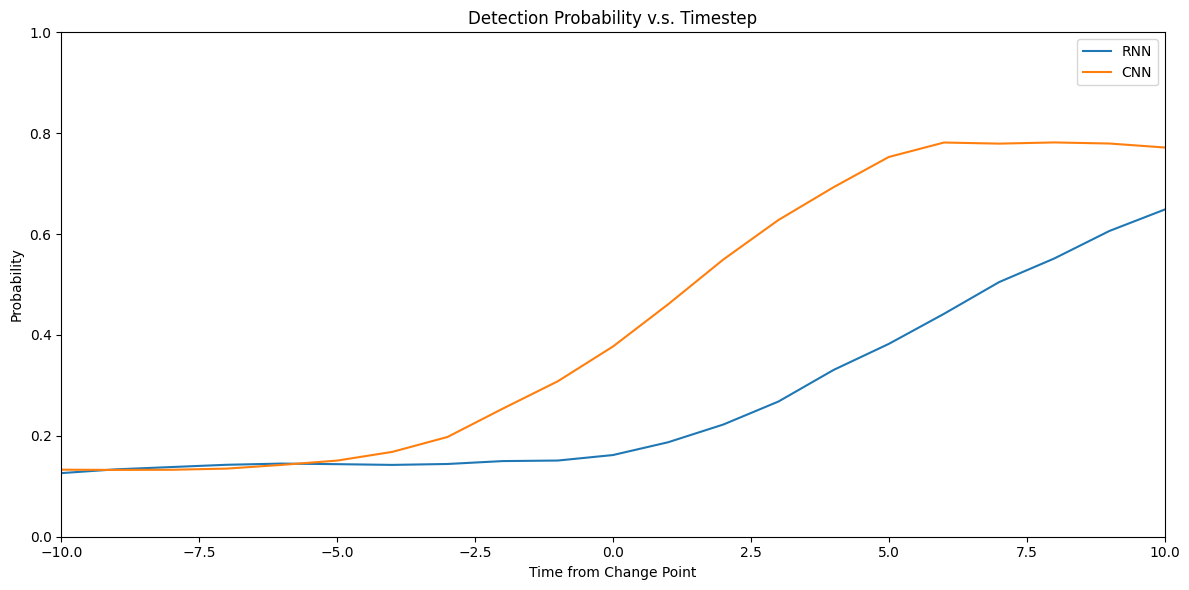

In [16]:
plt.figure(figsize=(12, 6))

dists_rnn = sorted(rnn_results.keys())
probs_rnn = [rnn_results[d] for d in dists_rnn]
plt.plot(dists_rnn, probs_rnn, label='RNN')

dists_cnn = sorted(cnn_results.keys())
probs_cnn = [cnn_results[d] for d in dists_cnn]
plt.plot(dists_cnn, probs_cnn, label='CNN')

plt.xlabel('Time from Change Point')
plt.ylabel('Probability')
plt.title('Detection Probability v.s. Timestep')
plt.legend()
plt.xlim(-10, 10)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Output 3 [output3.png] detection probability v.s. time from change point

In [25]:
print("CNN probs:")
print(f"t=-5: {rnn_results.get(-5, 'N/A'):.3f}")
print(f"t=-4: {rnn_results.get(-4, 'N/A'):.3f}")
print(f"t=-1: {rnn_results.get(-1, 'N/A'):.3f}")
print(f"t=0: {rnn_results.get(0, 'N/A'):.3f}")
print(f"t=5: {rnn_results.get(5, 'N/A'):.3f}")

print("\nCNN probs:")
print(f"t=-5: {cnn_results.get(-5, 'N/A'):.3f}")
print(f"t=-4: {cnn_results.get(-4, 'N/A'):.3f}")
print(f"t=-1: {cnn_results.get(-1, 'N/A'):.3f}")
print(f"t=0: {cnn_results.get(0, 'N/A'):.3f}")
print(f"t=5: {cnn_results.get(5, 'N/A'):.3f}")

CNN probs:
t=-5: 0.144
t=-4: 0.142
t=-1: 0.151
t=0: 0.162
t=5: 0.382

CNN probs:
t=-5: 0.151
t=-4: 0.168
t=-1: 0.308
t=0: 0.377
t=5: 0.753


The probabilities overall suggest the models are working. CNN seems to perform better in terms of probability at the end with a faster response after change, and both are maintaining low false alarm rates.

# testing on different sequence lengths

In [17]:
def test_on_different_lengths(model, lengths=[50, 75, 100, 125, 150], num_samples=200):
    model.eval()
    results = {}

    for length in lengths:
        correct = 0
        total = 0

        with torch.no_grad():
            for _ in range(num_samples):
                sequence, labels, change_point = generate_sequence(length, change_prob=0.8)

                seq_tensor = torch.FloatTensor(sequence).unsqueeze(0).to(device)
                probs = model(seq_tensor).squeeze().cpu().numpy()

                # Check if predictions match labels
                preds = (probs > 0.5).astype(float)
                correct += np.sum(preds == labels)
                total += length

        accuracy = correct / total
        results[length] = accuracy
        print(f"Length {length}: Accuracy = {accuracy:.4f}")

    return results


rnn_length_results = test_on_different_lengths(rnn_model)


Length 50: Accuracy = 0.8480
Length 75: Accuracy = 0.8929
Length 100: Accuracy = 0.9128
Length 125: Accuracy = 0.9168
Length 150: Accuracy = 0.9159


In [18]:
cnn_length_results = test_on_different_lengths(cnn_model)

Length 50: Accuracy = 0.8759
Length 75: Accuracy = 0.8541
Length 100: Accuracy = 0.8685
Length 125: Accuracy = 0.8725
Length 150: Accuracy = 0.8846


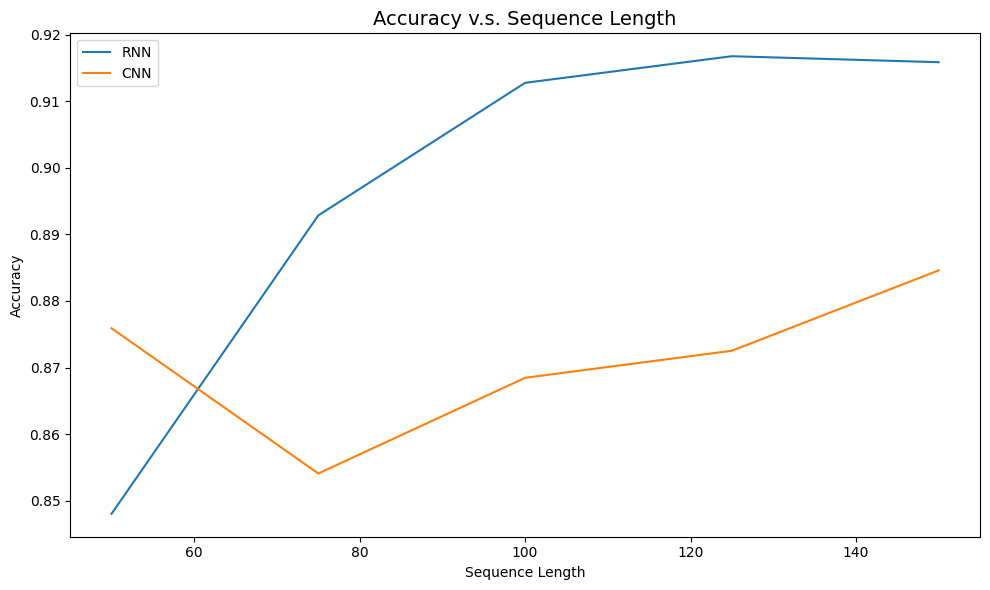

In [39]:
plt.figure(figsize=(10, 6))

lengths = sorted(rnn_length_results.keys())
rnn_accs = [rnn_length_results[l] for l in lengths]
cnn_accs = [cnn_length_results[l] for l in lengths]

plt.plot(lengths, rnn_accs, label='RNN')
plt.plot(lengths, cnn_accs, label='CNN')
plt.xlabel('Sequence Length')
plt.ylabel('Accuracy')
plt.title('Accuracy v.s. Sequence Length', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


Output 4 [output4.png] accuracy vs sequence length

When sequence length is great, RNN's generalization performance increased over CNN. It's likely that RNN's temporal integration is more robust for the greater range of the sequences.
In the early timesteps, CNN sequence uses azero-padding to handle, and the full convolution window wouldn't fit. That is, the convolutions only see padded zeros rather than the actual data.

In [40]:
# randomly generate and visualize testing cases
def visualize_prediction(model, model_name, num_examples=3):

    model.eval()

    fig, axes = plt.subplots(num_examples, 1, figsize=(14, 4*num_examples))
    if num_examples == 1:
        axes = [axes]

    with torch.no_grad():
        for i in range(num_examples):
            sequence, labels, change_point = generate_sequence(100, change_prob=1.0)
            seq_tensor = torch.FloatTensor(sequence).unsqueeze(0).to(device)

            probs = model(seq_tensor).squeeze().cpu().numpy()

            timesteps = np.arange(100)
            axes[i].plot(timesteps, probs, label='Predicted Probability')
            axes[i].plot(timesteps, labels, label='True Label', alpha=0.7, linestyle='--')

            axes[i].set_xlabel('Timestep', fontsize=11)
            axes[i].set_ylabel('Probability', fontsize=11)
            axes[i].set_title(f'{model_name} - Case {i+1}', fontsize=13)
            axes[i].legend(fontsize=10)
            axes[i].grid(True, alpha=0.3)
            axes[i].set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()


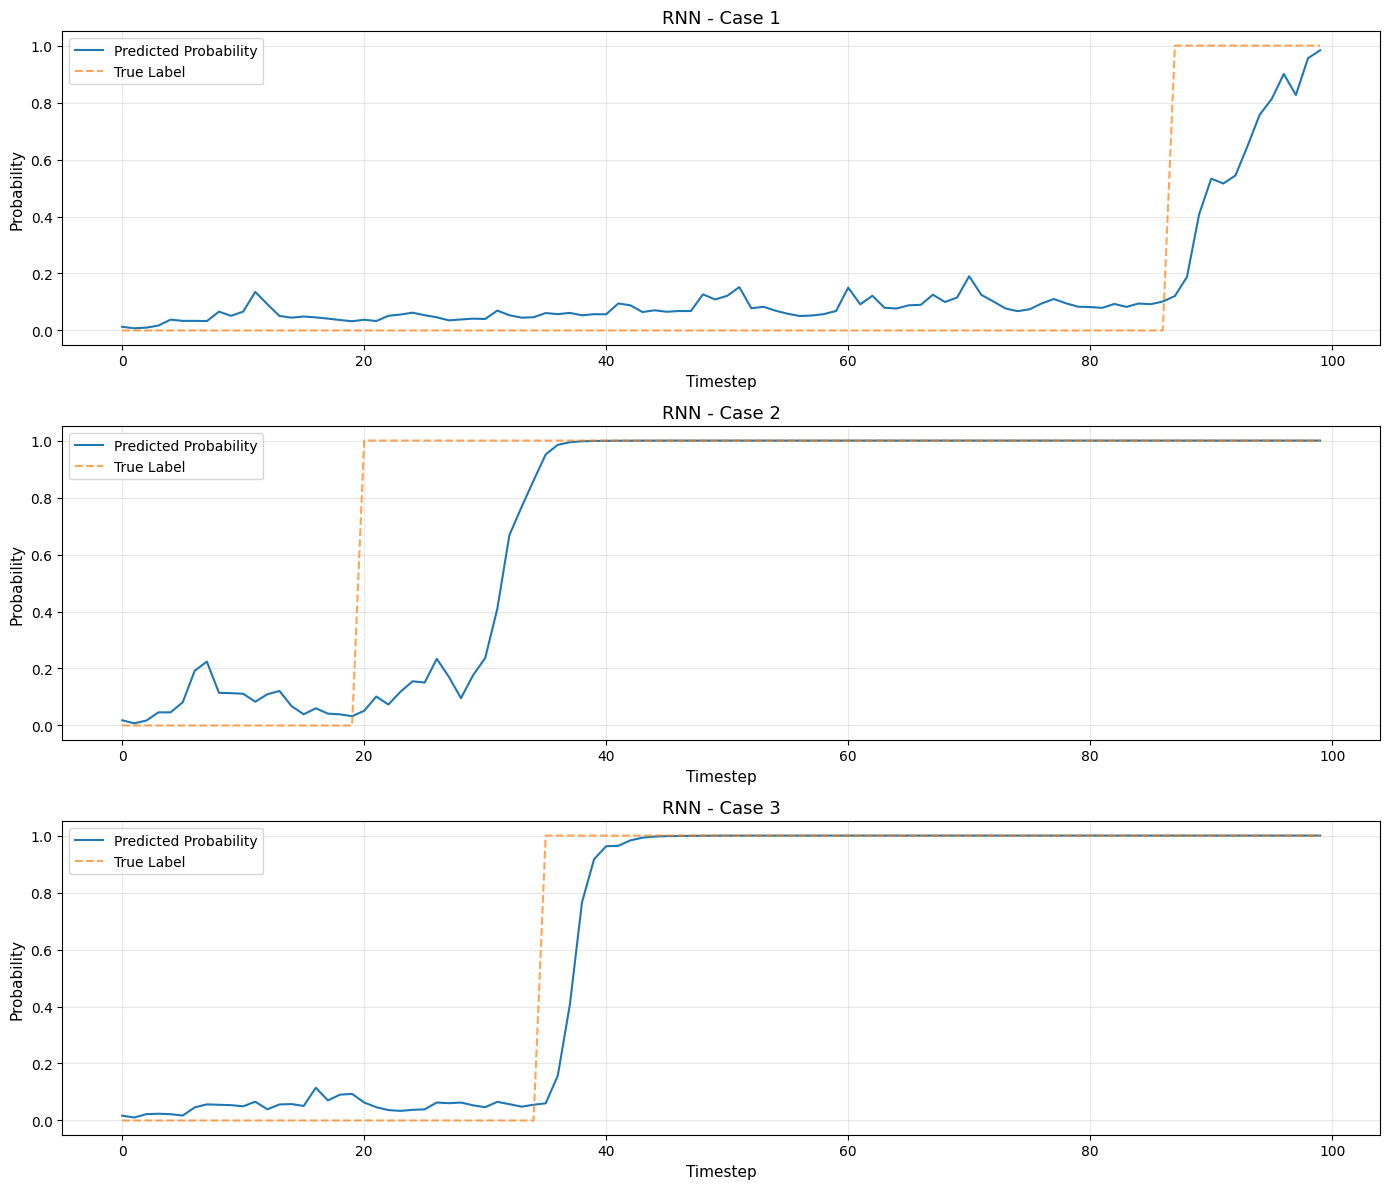

In [45]:
visualize_prediction(rnn_model, "RNN", num_examples=3)


Output 5 [output5.png] RNN prediction examples

The predictions overall worked. Case 3 shows an expected detection, where after change probability sharply increased from near 0 to near 1.
Case 2 has some spikes before changing and increased a bit late. The increase is still sharp. It's not as ideal, but is still acceptable, possibly because of some random fluctuations.
In case 1, as the change point is late, the behavior isn't as significantl. At t=100, it still reaches a high probability. A low false alarm is maintained among most steps, and reacted quickly after a change happened.

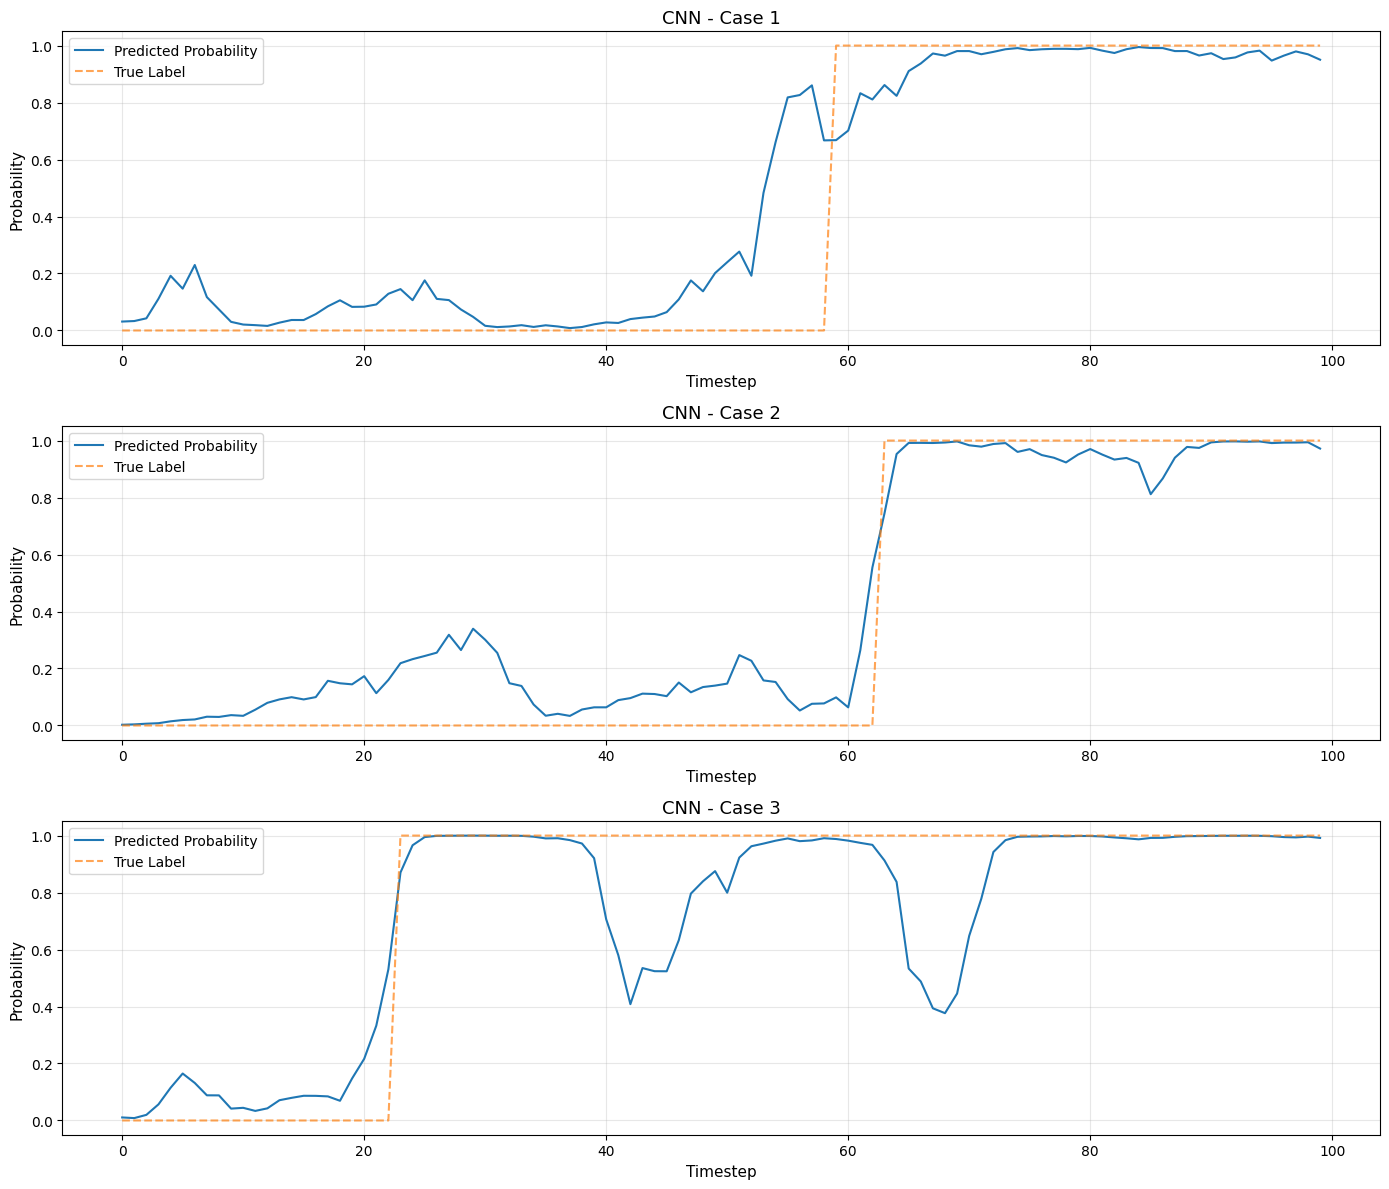

In [48]:
visualize_prediction(cnn_model, "CNN", num_examples=3)

Output 6 [output6.png] CNN predictions

Overall, the CNN examples are much noisy and less stable. In case 1, the probability increased around the change point, suggesting a fair detection. In case 2, before the change, it was noisy, and it turns more expected for the increase near change. In case 3, after change happened, it's much less stable. While it increased at change point as expected, afterwards, it dropped randomly to a significant extent. Overall, it suggests that CNN struggles at very early and very late change points. In the middle range, it works fairly.

Overall, the examples confirmed that CNN accuracy is lower than RNN, caused by its local windowing. For early change points, after the detection, it instably oscillates. For late change points, it seems to accumulate false alarms. RNN maintains a temporal state, so it avoids both of such issues and performs consistently.